# CASL 2F Example
This example models case 2F from the [CASL benchmark](https://corephysics.com/docs/CASL-U-2012-0131-004.pdf). \
The 2F case calculates the k-eigenvalue and power distribution of a 2D PWR fuel assembly with pyrex control rods.

In [ ]:
import os
import sys
import numpy as np
import csv
from collections import Counter
import matplotlib.pyplot as plt

## Using this Notebook
Before running this example, make sure that the **Python module of OpenSn** was installed.

### Converting and Running this Notebook from the Terminal
To run this notebook from the terminal, simply type:

`jupyter nbconvert --to python --execute <notebook_name>.ipynb`.

To run this notebook in parallel (for example, using 4 processes), simply type:

`mpiexec -n 4 jupyter nbconvert --to python --execute <notebook_name>.ipynb`.

In [ ]:
from mpi4py import MPI
size = MPI.COMM_WORLD.size
rank = MPI.COMM_WORLD.rank

if rank == 0:
    print(f"Running with {size} MPI processors.")

## Import Requirements

Import required classes and functions from the Python interface of OpenSn. \
Make sure that the path to PyOpenSn is appended to Python's PATH.

In [ ]:
# assuming that the execute dir is the notebook dir
# this line is not necessary when PyOpenSn is installed using pip
sys.path.append("../../..")

from pyopensn.mesh import FromFileMeshGenerator, PETScGraphPartitioner
from pyopensn.xs import MultiGroupXS
from pyopensn.aquad import GLCProductQuadrature2DXY
from pyopensn.solver import DiscreteOrdinatesProblem, PowerIterationKEigenSolver
from pyopensn.logvol import LogicalVolume, RCCLogicalVolume
from pyopensn.fieldfunc import *
from pyopensn.context import UseColor, Finalize

Disable colorized output

In [ ]:
UseColor(False)

## Mesh File
A mesh (.obj file) containing a quarter of the reactor assembly is loaded.\
The mesh and its block IDs are shown below:
<div style="display: flex; gap: 1rem; align-items: flex-start;">
  <img
    src="./images/tutorials_lbs_keigen_CASL_2F.png"
    alt="Mesh and Material Layout for the pin cell problem"
    style="width:65%;"
  >
</div>

In [ ]:
meshgen = FromFileMeshGenerator(filename="lattice_2F.obj")
grid = meshgen.Execute()
grid.SetOrthogonalBoundaries()
grid.ExportToPVTU("lattice_2F_mesh")

## Cross Sections
We load 361-group cross sections from an h5 file that were generated using OpenMC. 

In [ ]:
xs_filepath = "./mgxs_2f_one_eighth_SHEM-361.h5"

# The materials for which cross sections were generated by OpenMC
h5_mat_names = [
                'fuel',          # fuel pin
        		'clad',          # fuel cladding
        		'gap',           # gap in fuel rod
        		'pyrex_gap',     # gap in pyrex control rod
                'pyrex_guide',   # guidetube cladding
                'it-clad',       # instrumentation tube cladding  
        		'it-water-in',   # instrument tube interior water
        		'it-water-out',  # instrument tube exterior water
                'moderator',     # water outside fuel cladding
        		'pyrex',         # pyrex poison material
                'pyrex_clad',    # cladding around pyrex material
        		'pyrex_water',   # water in control rod lattice
        		'water_outside'  # water in the gap between assemblies
                ]

# Create a dictionary of cross sections using MultiGroupXS.LoadFromOpenMC()
xs_dict = {}
xs_list = []
for name in h5_mat_names:
    xs_dict[name] = MultiGroupXS()
    xs_dict[name].LoadFromOpenMC(xs_filepath, name, 294.0)
    xs_list = np.append(xs_list, xs_dict[name])

block_ids = [i for i in range(0, len(xs_list))]

scat_order = 3 # The cross section file includes 8th order scattering, however the problem has been simplified for this tutorial

num_groups = xs_list[0].num_groups

## Angular Quadrature
We create a product Gauss-Legendre-Chebyshev angular quadrature and pass the **total** number of polar cosines
(here `n_polar = 2`) and the number of azimuthal subdivisions in **four quadrants** (`n_azimuthal = 4`).

For more accurate results, we suggest using `n_polar = 8` and `n_azimuthal = 32`

In [ ]:
pquad = GLCProductQuadrature2DXY(n_polar=2, n_azimuthal=4, scattering_order=scat_order)

## Linear Boltzmann Solver
The tolerances for this tutorial have been set such that the calculation time is shortened. \
For more accurate results, it is recommended that these tolerances are decreased to better produce the desired convergence.

### Options for the Linear Boltzmann Problem (LBS)

In [ ]:
group_sets = [
            {
            "groups_from_to"         : (0, num_groups - 1),
            "angular_quadrature"     : pquad,
            "angle_aggregation_type" : "polar",
            "inner_linear_method"    : "classic_richardson",
            "l_abs_tol"              : 1.0e-2,
            "l_max_its"              : 100,
            }
        ]

# Specify boundary conditions
bound_conditions = [
                    { 'name' : "xmin", 'type' : "reflecting" },
                    { 'name' : "xmax", 'type' : "reflecting" },
                    { 'name' : "ymin", 'type' : "reflecting" },
                    { 'name' : "ymax", 'type' : "reflecting" }
                    ]

# Map material cross section in h5 file to the block IDs in the mesh file
xs_mapping = []
for i in range(0,xs_list.shape[0]):
    xs_mapping.append({'block_ids' : [i], 'xs' : xs_list[i]})

#Pass the mesh, group sets, cross sections, and boundary conditions to the problem
phys = DiscreteOrdinatesProblem( 
                                 mesh=grid,
                                 num_groups=num_groups,
                                 groupsets=group_sets,
                                 xs_map=xs_mapping,
                                 boundary_conditions=bound_conditions
                                )

# Set run options
phys.SetOptions(
                verbose_inner_iterations=True,
                verbose_outer_iterations=True,
                power_default_kappa=1.0,
                power_normalization=1.0,
                save_angular_flux=False
               )


### Putting the Linear Boltzmann Solver Together
We then create the physics solver, initialize it, and execute it.

In [ ]:
k_solver = PowerIterationKEigenSolver(
                                      problem = phys,
                                      k_tol = 1.0e-2
                                     )
k_solver.Initialize()
k_solver.Execute()

## Post-Processing Results

### k-Eigenvalue Solution

In [ ]:
keff = k_solver.GetEigenvalue()
if rank ==0:
    print(f"k-Eigenvalue = {keff:.6f}")

The final k-eigenvalue is calculated to be 0.967156.


### Power Distribution Solution
The power distribution for each cell is obtained by multiplying the flux in the cell by the fuel's fission cross section. \
To do this, logical volumes must be created for each cell using assembly dimensions calculated in the functions below.

In [ ]:
def compute_cell_center(i, j, offset_x, offset_y):
    x_center = i * pitch + offset_x 
    y_center = j * pitch + offset_y
    return x_center, y_center

def read_csv_to_2d_array(file_path):
    with open(file_path, newline="", encoding="utf-8") as csvfile:
        reader = csv.reader(csvfile)
        data = [row for row in reader]
    return np.asarray(data)

def count_frequencies(data):
    flattened_data = [item for row in data for item in row]
    return Counter(flattened_data)

In [ ]:
lattice_csv = read_csv_to_2d_array("FA_cell_names_1_family.csv") # CSV containing assembly fuel pin locations
cell_frequencies = count_frequencies(lattice_csv)

num_cells = lattice_csv.shape[0]                          # The assembly is a 17x17 grid, thus num_cells = 17
num_cells_quarter = np.ceil(num_cells/2).astype(np.int64) # Number of cells across a quarter of assembly, 9

# Assembly geometry data
pitch = 1.26
offset_x = -4.705
offset_y =  4.705 - 16*pitch
quarter_lattice_center = -5.375

In [ ]:
sig_f = np.array(xs_dict["fuel"].sigma_f) # Fuel fission cross sections
fflist = phys.GetScalarFieldFunctionList() # Field function list

# Create and calculate table of power distributions for each fuel cell
val_table = np.zeros([num_cells, num_cells])
for i in range(num_cells):
    for j in range(num_cells):
        if lattice_csv[i, j] == "fu":   # if the lattice index is fuel, calculate the power
            # Find the cell center and create a Right Circular Cylinder (RCC) logical volume around it using the pin radius
            x_center, y_center = compute_cell_center(i, j, offset_x, offset_y)
            my_lv = RCCLogicalVolume(r=0.4060, x0=x_center, y0=y_center, z0=-1.0, vz=2.0)
            val = 0
            for g in range(0, num_groups):
                ffi = FieldFunctionInterpolationVolume()
                ffi.SetOperationType("sum")
                ffi.SetLogicalVolume(my_lv)
                ffi.AddFieldFunction(fflist[g])
                ffi.Initialize()
                ffi.Execute()
                val_g = ffi.GetValue()
                val += val_g * sig_f[g]
            val_table[i, j] = val

In [ ]:
# Create a power distribution map for the whole table using only a quarter assembly
val_table = np.flip(val_table, axis=1)
A = val_table[:num_cells_quarter, :num_cells_quarter]
A[:,-1] *= 2.
A[-1,:] *= 2.
val_table_quarter = A.copy()
A_flipped = np.flip(A, axis=1)
B = np.hstack([A,A_flipped[:,1:]])
B_flipped = np.flip(B, axis=0)
val_table = np.vstack([B,B_flipped[1:,:]])

# Normalize the power distribution
norm = np.sum(val_table) / cell_frequencies["fu"]
val_table /= norm

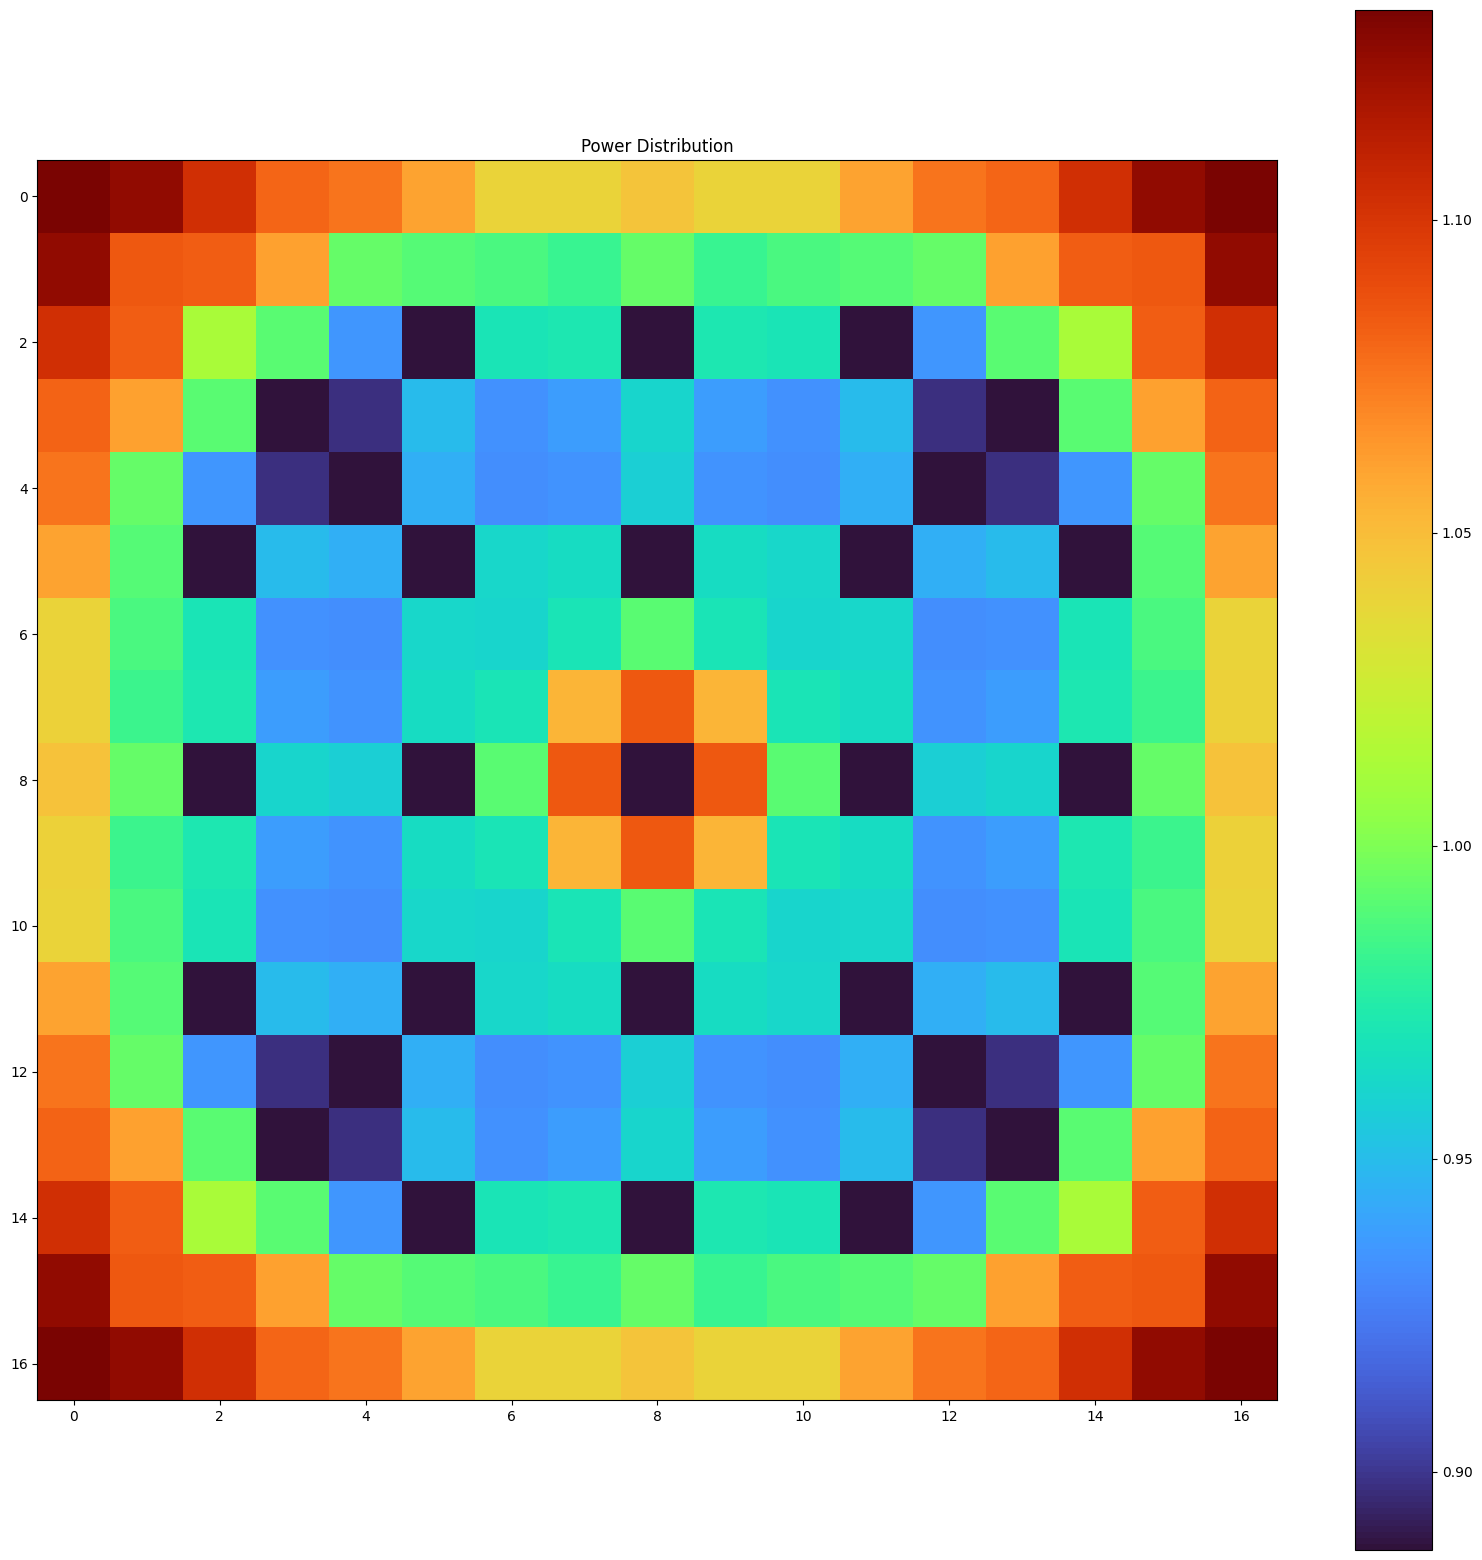

In [15]:
plt.figure(figsize=(20,20))
plt.imshow(val_table, cmap='turbo')
plt.title('Power Distribution')
plt.colorbar()
plt.clim([np.min(val_table[val_table > 0]),np.max(val_table[val_table > 0])])
plt.show()

## Finalize (for Jupyter Notebook only)

In Python script mode, PyOpenSn automatically handles environment termination. However, this
automatic finalization does not occur when running in a Jupyter notebook, so explicit finalization
of the environment at the end of the notebook is required. Do not call the finalization in Python
script mode, or in console mode.

Note that PyOpenSn's finalization must be called before MPI's finalization.

In [ ]:
MPI.COMM_WORLD.Barrier()

In [ ]:
from IPython import get_ipython

def finalize_env():
    Finalize()
    MPI.Finalize()

ipython_instance = get_ipython()
if ipython_instance is not None:
    ipython_instance.events.register("post_execute", finalize_env)